In [ ]:
import skimage
import numpy as np
import torch
import matplotlib.pyplot as plt


In [ ]:
# 0填充
img_in = skimage.io.imread("/home/lqg/LX/论文硬币/y/1.bmp")
img_in = np.float64(img_in)
img_in = img_in/255
plt.subplot(1,2,1)
skimage.io.imshow(img_in)
img_in = torch.from_numpy(img_in).float().to("cuda:1")


y_k = torch.fft.fft2(img_in)            
y_k = torch.fft.fftshift(y_k)           
y = torch.zeros([128,128],dtype=torch.complex64,device="cuda:1")
y[64-15:64+16,64-15:64+16] = y_k[:,:]
img_out = torch.fft.ifft2(y)
img_out = img_out.cpu().numpy()
img_out = np.abs(img_out)
img_out = img_out/np.max(img_out)
plt.subplot(1,2,2)
skimage.io.imshow(img_out)
skimage.io.imsave("/home/liuqg/LX2/zero2.bmp",img_out)



In [ ]:
img_in2 = img_in = skimage.io.imread("/home/liuqg/LX2/121.bmp")
img_in2 = img_in2/255
img_in2 = torch.from_numpy(img_in2).float()

y_k2 = torch.fft.fft2(img_in2)  
k2 = torch.fft.fftshift(y_k2)
k2 = torch.abs(k2)
skimage.io.imshow(k2.numpy())

In [ ]:
a = skimage.io.imread("/home/liuqg/LX2/y.bmp")
b = skimage.io.imread("/home/liuqg/LX2/s.bmp")
# c = skimage.io.imread("/home/liuqg/LX2/43_25_sample/best/865.bmp")
# c = skimage.io.imread("/home/liuqg/LX2/44_25_u1/best/952.bmp")
# c = skimage.io.imread("/home/liuqg/LX2/45_25_u3/best/955.bmp")
c = skimage.io.imread("/home/liuqg/LX2/ball/5996.bmp")

d = skimage.io.imread("/home/liuqg/LX2/z_pros.png")
# e = skimage.io.imread("/home/liuqg/LX2/11.bmp")
# e = skimage.transform.resize(e,(128,128))
# e = np.float64(e)
# e = e/np.max(e)

a = np.float64(a)
b = np.float64(b)
c = np.float64(c)
d = np.float64(d)

c = 0.8*c+0.2*d

print(a.max(),b.max(),c.max(),d.max())
a = a/np.max(a)
b = b/np.max(b)
c = c/np.max(c)
d = d/np.max(d)

# # #自适应直方图均衡化
# c = skimage.exposure.equalize_adapthist(c, clip_limit=0.01, nbins=128)
# c = c/np.max(c)
# 图像锐化
# c = skimage.filters.unsharp_mask(c, radius=2, amount=0.3)
# c = c/np.max(c)
# c = 0.5*c+0.5*d
# c = c/np.max(c)


plt.subplot(1,4,1)
skimage.io.imshow(a,cmap="gray")
plt.subplot(1,4,2)
skimage.io.imshow(b,cmap="gray")
plt.subplot(1,4,3)
skimage.io.imshow(c,cmap="gray")
plt.subplot(1,4,4)
skimage.io.imshow(d,cmap="gray")


#比较相似度
print("ssim_out:",skimage.metrics.structural_similarity(a[:-1,:-1],c[1:,1:]))
print("ssim_zero:",skimage.metrics.structural_similarity(a[:-1,:-1],d[1:,1:]))
#比较峰值信噪比
print("psnr_outCUDA_VISIBLE_DEVICES=0 python A_PCsampling_demo.py:",skimage.metrics.peak_signal_noise_ratio(a[:-1,:-1],c[1:,1:]))
print("psnr_zero:",skimage.metrics.peak_signal_noise_ratio(a[:-1,:-1],d[1:,1:]))
skimage.io.imsave("/home/liuqg/LX2/1111.bmp",c)
skimage.io.imsave("/home/liuqg/LX2/2222.bmp",d)


In [ ]:
a = skimage.io.imread("/home/liuqg/LX2/y.bmp")
b = skimage.io.imread("/home/liuqg/LX2/s2.bmp")
# c = skimage.io.imread("/home/liuqg/LX2/43_25_sample/best/865.bmp")
# c = skimage.io.imread("/home/liuqg/LX2/42_25_sample2/best/1097.bmp")
# c = skimage.io.imread("/home/liuqg/LX2/45_25_u3/best/955.bmp")
# c = skimage.io.imread("/home/liuqg/LX2/41_25_u4//1037.bmp")
# c = skimage.io.imread("/home/liuqg/LX2/4444/1507.bmp")
# c = skimage.io.imread("/home/liuqg/LX2/ball2/4412.bmp")
c = skimage.io.imread("/home/liuqg/LX2/1_1200/3303.bmp")
d = skimage.io.imread("/home/liuqg/LX2/z_pros_31.png")
# e = skimage.io.imread("/home/liuqg/LX2/11.bmp")
# e = skimage.transform.resize(e,(128,128))
# e = np.float64(e)
# e = e/np.max(e)

a = np.float64(a)
b = np.float64(b)
c = np.float64(c)
d = np.float64(d)

c = 0.7*c+0.3*d

print(a.max(),b.max(),c.max(),d.max())
a = a/np.max(a)
b = b/np.max(b)
# c = np.power(c,0.5)
c = c/np.max(c)

#直方图均衡化
# c = skimage.exposure.equalize_hist(c)
# c = c/np.max(c)

# 调整灰度图像的对比度
# c = skimage.exposure.adjust_gamma(c, gamma=0.9, gain=1)
# c = c/np.max(c)
# # 调整灰度图像的饱和度
# c = skimage.exposure.adjust_sigmoid(c, cutoff=0.2, gain=3,inv=False)
# # 图像锐化
# c = skimage.filters.unsharp_mask(c, radius=0.2, amount=0.5)
# #自适应直方图均衡化
# c = skimage.exposure.equalize_adapthist(c, clip_limit=0.01, nbins=128)

d = d/np.max(d)

plt.subplot(1,4,1)
skimage.io.imshow(a,cmap="gray")
plt.subplot(1,4,2)
skimage.io.imshow(b,cmap="gray")
plt.subplot(1,4,3)
skimage.io.imshow(c,cmap="gray")
plt.subplot(1,4,4)
skimage.io.imshow(d,cmap="gray")

#比较相似度
print("ssim_out:",skimage.metrics.structural_similarity(a[:-1,:-1],c[1:,1:]))
print("ssim_zero:",skimage.metrics.structural_similarity(a[:-1,:-1],d[1:,1:]))
#比较峰值信噪比
print("psnr_out:",skimage.metrics.peak_signal_noise_ratio(a[:-1,:-1],c[1:,1:]))
print("psnr_zero:",skimage.metrics.peak_signal_noise_ratio(a[:-1,:-1],d[1:,1:]))
skimage.io.imsave("/home/liuqg/LX2/1111.bmp",c)

/tmp/ipykernel_24222/3216903392.py:37: UserWarning: /home/liuqg/LX/1111.bmp is a low contrast image
  skimage.io.imsave("/home/liuqg/LX/1111.bmp",c)
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.


ssim_out: 0.990853760407506
ssim_zero: 0.9864846285098796
psnr_out: 38.138294462347105
psnr_zero: 35.19970128845096


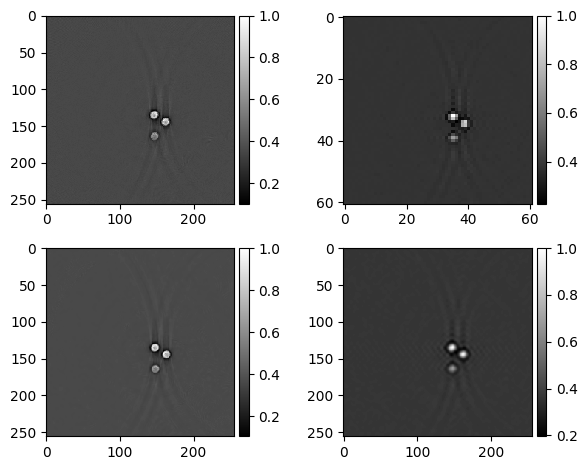

In [5]:
a = skimage.io.imread("/home/liuqg/LX/image1/y.png")
b = skimage.io.imread("/home/liuqg/LX/image1/s.png")
c = skimage.io.imread("/home/liuqg/LX/1_ball/5144.bmp")
d = skimage.io.imread("/home/liuqg/LX/image1/z.png")

a = np.float64(a)
a = skimage.transform.resize(a,(256,256))
b = np.float64(b)
c = np.float64(c)
d = np.float64(d)



a = a/np.max(a)
b = b/np.max(b)
c = c/np.max(c)
d = d/np.max(d)

# c = 0.7*c + 0.3*d
c = c/np.max(c)

plt.subplot(2,2,1)
skimage.io.imshow(a,cmap="gray")
plt.subplot(2,2,2)
skimage.io.imshow(b,cmap="gray")
plt.subplot(2,2,3)
skimage.io.imshow(c,cmap="gray")
plt.subplot(2,2,4)
skimage.io.imshow(d,cmap="gray")

#比较相似度
print("ssim_out:",skimage.metrics.structural_similarity(a[:-1,:-1],c[1:,1:]))
print("ssim_zero:",skimage.metrics.structural_similarity(a[:-1,:-1],d[1:,1:]))
#比较峰值信噪比
print("psnr_out:",skimage.metrics.peak_signal_noise_ratio(a[:-1,:-1],c[1:,1:]))
print("psnr_zero:",skimage.metrics.peak_signal_noise_ratio(a[:-1,:-1],d[1:,1:]))
skimage.io.imsave("/home/liuqg/LX/1111.bmp",c)

# 针状图

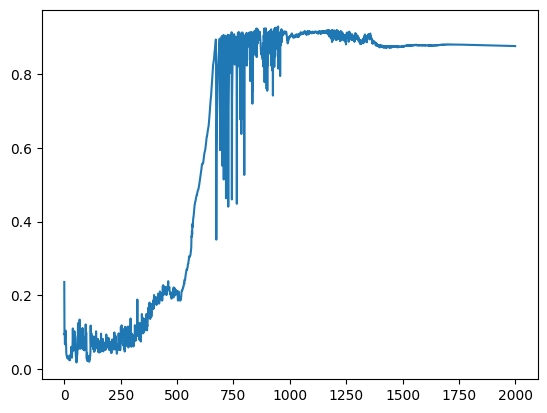

ssim_out: 0.9289350161943007 相似度最大图片: 948
psnr_out: 29.835969650627572


In [33]:
import skimage
import numpy as np
import torch
import matplotlib.pyplot as plt

a = skimage.io.imread("/home/lqg/LX/论文硬币/y/1.bmp")
# a = np.rot90(a,2)
# a = skimage.color.rgb2gray(a)
# a = skimage.transform.resize(a,(256,256))
# a = np.rot90(a)
a = np.float64(a)
a = a/np.max(a)
y = []
for i in range(0,2000):
    b = skimage.io.imread("/media/lqg/TOSHIBA EXT/刘轩/仿真硬币迭代/1 5 30/"+str(i)+".bmp")
    b = np.float64(b)
    b = b/np.max(b)
    # b = np.power(b,0.832)
    # b = b/np.max(b)
    n = skimage.metrics.structural_similarity(a,b)
    y.append(n)
x = np.arange(0,2000)
plt.plot(x,y)
plt.show()
y = np.array(y) 
print("ssim_out:",y.max(),"相似度最大图片:",y.argmax())
c = skimage.io.imread("/media/lqg/TOSHIBA EXT/刘轩/仿真硬币迭代/1 5 30/"+ str(y.argmax())+".bmp")
c = np.float64(c)
c = c/np.max(c)
print("psnr_out:",skimage.metrics.peak_signal_noise_ratio(c,a))



#sssim_out: 0.8988530085655748 相似度最大图片: 935
#psnr_out: 27.89790717325871



In [122]:
import skimage
import numpy as np
import torch
import matplotlib.pyplot as plt

a = skimage.io.imread("/home/lqg/LX2/dog/dog/1/5.bmp")
# print(a.shape)
a = np.float64(a)
a = a/np.max(a)
y = skimage.io.imread("/home/lqg/LX2/dog/Unet数据/1%/5out.bmp")
y = np.float64(y)
y = y/np.max(y)
S = skimage.metrics.structural_similarity(a,y)
print('{:.4f}'.format(S))
P = skimage.metrics.peak_signal_noise_ratio(a,y)
print('{:.4f}'.format(P))

np.fft.ifft2

0.7218
20.8910


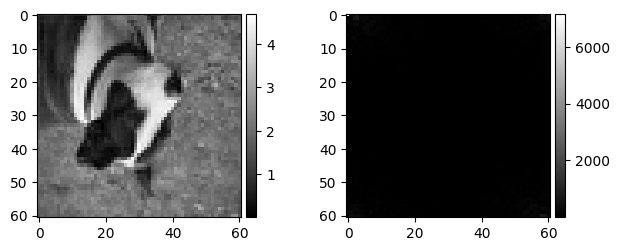

In [144]:
import skimage
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.io as sio

y_k = sio.loadmat("/home/lqg/LX2/1采样/mat/20.mat")["image_k"]
# 
plt.subplot(2,2,1)
im = np.abs(np.fft.ifft2(y_k))
skimage.io.imshow(im,cmap='gray')

y_k = np.fft.fft2(im)
k = np.abs(y_k)
plt.subplot(2,2,2)
skimage.io.imshow(k,cmap='gray')


# y_k = torch.from_numpy(y_k)
# y_k = np.fft.fftshift(np.fft.fft2(np.rot90(np.abs(np.fft.ifft2(y_k)),2)))
# im1 = np.rot90(np.abs(np.fft.ifft2(y_k)),2)
# im1 = np.abs(np.fft.ifft2(y_k))
# plt.subplot(2,2,3)
# skimage.io.imshow(im1,cmap='gray')

# y_k = np.fft.fft2(im1)
# k = np.abs(y_k)
# plt.subplot(2,2,4)
# skimage.io.imshow(k,cmap='gray')

# im2 = np.rot90(np.abs(np.fft.ifft2(y_k)),2)
# im2  = np.abs(im2)
# plt.subplot(2,2,3)
# skimage.io.imshow(im2,cmap='gray')

# y_k2 = np.fft.fft2(im2)
# k2 = np.abs(y_k2)
# plt.subplot(2,2,4)
# skimage.io.imshow(k2,cmap='gray')

/home/lqg/anaconda3/envs/LX/lib/python3.8/site-packages/skimage/io/_plugins/matplotlib_plugin.py:150: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


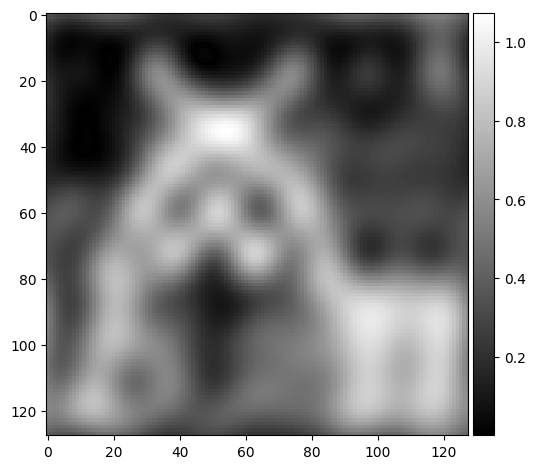

In [10]:
import skimage
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.io import loadmat,savemat
k = loadmat("/home/lqg/LX2/论文狗.mat")["f"]
k = k[30-6:30+7,30-6:30+7]
z = np.zeros([128,128],dtype=np.complex64)
z[64-6:64+7,64-6:64+7] = k
a = np.fft.ifft2(z)
a = abs(a)
a = np.rot90(a,2)
skimage.io.imshow(a,cmap = "gray")

In [ ]:
import skimage
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.io as sio

y = skimage.io.imread(r'/home/liuqg/LX2/y.bmp')
y = np.float64(y)
y = y/np.max(y)
y_k = np.fft.fft2(y)
y_k = np.fft.fftshift(y_k)
y_k = np.abs(y_k)
print(y_k.max())
plt.subplot(1,2,1)
skimage.io.imshow(y_k,cmap="hot")
# x = sio.loadmat(r"/home/liuqg/LX2/y_31.mat")["f"]
# # print(type(x))
# x_k = np.abs(x)
# print(x_k.max())
# plt.subplot(1,2,2)
# skimage.io.imshow(x_k,cmap="hot")

8403.290196078431


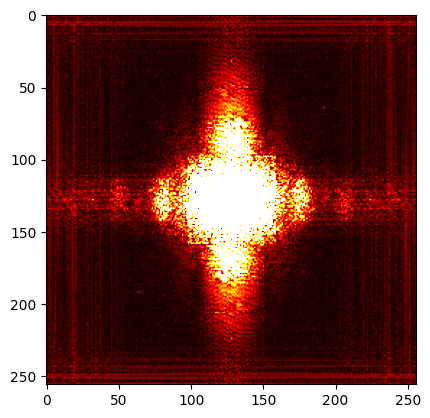

In [13]:
import skimage
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.io as sio
y_k = skimage.io.imread("/home/liuqg/LX/4074.bmp")
# y_k = skimage.color.rgb2gray(y_k) 
# y_k = skimage.transform.resize(y_k,(61,61))
y_k = y_k/np.max(y_k)
y_k = np.fft.fftshift(np.fft.fft2(y_k))
y_k = np.abs(y_k)
print(y_k.max())
# skimage.io.imshow(y_k,cmap="hot")
plt.imshow(y_k,cmap="hot",vmin=0,vmax=10)



In [9]:
import skimage
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.io as sio

y_k = sio.loadmat("/home/liuqg/LX/coinmat/sf.mat")["f"]
y_k.shape
# k = y_k[30-15:30+16,30-15:30+16]
# k.shape

(61, 61)